# KAIST1 — Import & Visualize

Interactive notebook for exploring the KAIST1 / NOVIC+ compound-fault motor dataset (Yi et al., arXiv 2505.24001v4).

**`.npy` file structure:** `(N, 102 400, 9)` float64 — 4 s × 25.6 kHz, 9 synchronous channels.

Channel mapping (CONFIRMED from Zenodo description):

| ch | Sensor |
|---|---|
| 0 | Vibration Bearing A — perpendicular to ground |
| 1 | Vibration Bearing A — parallel to ground |
| 2 | Vibration Bearing B — perpendicular to ground |
| 3 | Vibration Bearing B — parallel to ground |
| 4 | Temperature Bearing A (°C) |
| 5 | Temperature Bearing B (°C) |
| 6 | Torque load |
| 7 | Shaft RPM after gearbox (rotor side, slower) |
| 8 | Shaft RPM before gearbox (motor side, ch8/ch7 ≈ 2.07) |

Every file is opened with `mmap_mode='r'` to keep memory usage low.

## 1. Imports & configuration

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import kurtosis

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ROOT = Path(r'd:\[Lab] HUST\Dr Liou - Multi modal\KAIST1')
FS = 25_600                 # sampling frequency (Hz)
SEG_SAMPLES = 102_400       # 4 s segment
N_CH = 9
CH_NAMES = [
    'Vib BearA perp', 'Vib BearA para', 'Vib BearB perp', 'Vib BearB para',
    'Temp BearA (degC)', 'Temp BearB (degC)',
    'Torque load',
    'RPM rotor (after gearbox)', 'RPM motor (before gearbox)',
]

# Bearing geometry (NSK 6205, paper Section 5.1)
N_BALLS, D_BALL, D_PITCH = 9, 7.90, 38.5
DD = D_BALL / D_PITCH
FTF_R = 0.5 * (1 - DD)
BSF_R = (D_PITCH / (2 * D_BALL)) * (1 - DD ** 2)
BPFO_R = (N_BALLS / 2) * (1 - DD)
BPFI_R = (N_BALLS / 2) * (1 + DD)
print(f'FTF/fr={FTF_R:.4f}  BSF/fr={BSF_R:.4f}  BPFO/fr={BPFO_R:.4f}  BPFI/fr={BPFI_R:.4f}')

FILES = {
    'valid_subsetA': 'valid_data_4s_clf_subsetA.npy',
    'valid_subsetB': 'valid_data_4s_clf_subsetB.npy',
    'valid_subsetC': 'valid_data_4s_clf_subsetC.npy',
    'valid_subsetE': 'valid_data_4s_clf_subsetE.npy',
    'train_subsetB': 'train_data_4s_clf_subsetB.npy',
    'train_subsetC': 'train_data_4s_clf_subsetC.npy',
}
print('Working dir:', ROOT)

FTF/fr=0.3974  BSF/fr=2.3341  BPFO/fr=3.5766  BPFI/fr=5.4234
Working dir: d:\[Lab] HUST\Dr Liou - Multi modal\KAIST1


## 2. File overview (mmap, no RAM blow-up)

In [19]:
arrs = {}
rows = []
for tag, fname in FILES.items():
    p = ROOT / fname
    if not p.exists():
        print(f'[skip] missing {fname}')
        continue
    a = np.load(p, mmap_mode='r')
    arrs[tag] = a
    rows.append((tag, a.shape, str(a.dtype),
                 round(p.stat().st_size / 1e9, 3)))

print(f'{"tag":18s} {"shape":>22s}  {"dtype":<10s} {"size GB":>10s}')
print('-' * 65)
for r in rows:
    print(f'{r[0]:18s} {str(r[1]):>22s}  {r[2]:<10s} {r[3]:>10.2f}')

tag                                 shape  dtype         size GB
-----------------------------------------------------------------
valid_subsetA            (336, 102400, 9)  float64          2.48
valid_subsetB            (336, 102400, 9)  float64          2.48
valid_subsetC            (333, 102400, 9)  float64          2.46
valid_subsetE            (100, 102400, 9)  float64          0.74
train_subsetB           (2690, 102400, 9)  float64         19.83
train_subsetC           (2667, 102400, 9)  float64         19.66


## 3. Pick a subset and a sample to explore

Change `SUBSET` and `SAMPLE_IDX` to inspect different recordings.

In [20]:
SUBSET = 'valid_subsetC'    # 'valid_subsetA' | 'valid_subsetB' | 'valid_subsetC' | 'valid_subsetE' | 'train_subsetB' | 'train_subsetC'
SAMPLE_IDX = 0

arr = arrs[SUBSET]
print(f'Selected: {SUBSET}, shape={arr.shape}, sample={SAMPLE_IDX}')

sample = np.asarray(arr[SAMPLE_IDX])         # (102400, 9)
t = np.arange(SEG_SAMPLES) / FS              # time vector (s)
rotor_rpm = float(sample[::256, 7].mean())   # ch7 = rotor side (slower); bearings rotate at this speed
fr = rotor_rpm / 60
print(f'Sample shape: {sample.shape}, duration: {SEG_SAMPLES / FS} s')
print(f'Rotor f_r = {fr:.2f} Hz  ->  BPFO={BPFO_R*fr:.1f} Hz, BPFI={BPFI_R*fr:.1f} Hz, '
      f'FTF={FTF_R*fr:.1f} Hz, BSF={BSF_R*fr:.1f} Hz')

Selected: valid_subsetC, shape=(333, 102400, 9), sample=0
Sample shape: (102400, 9), duration: 4.0 s
Rotor f_r = 20.13 Hz  ->  BPFO=72.0 Hz, BPFI=109.2 Hz, FTF=8.0 Hz, BSF=47.0 Hz


## 4. Waveform of all 9 channels (one sample)

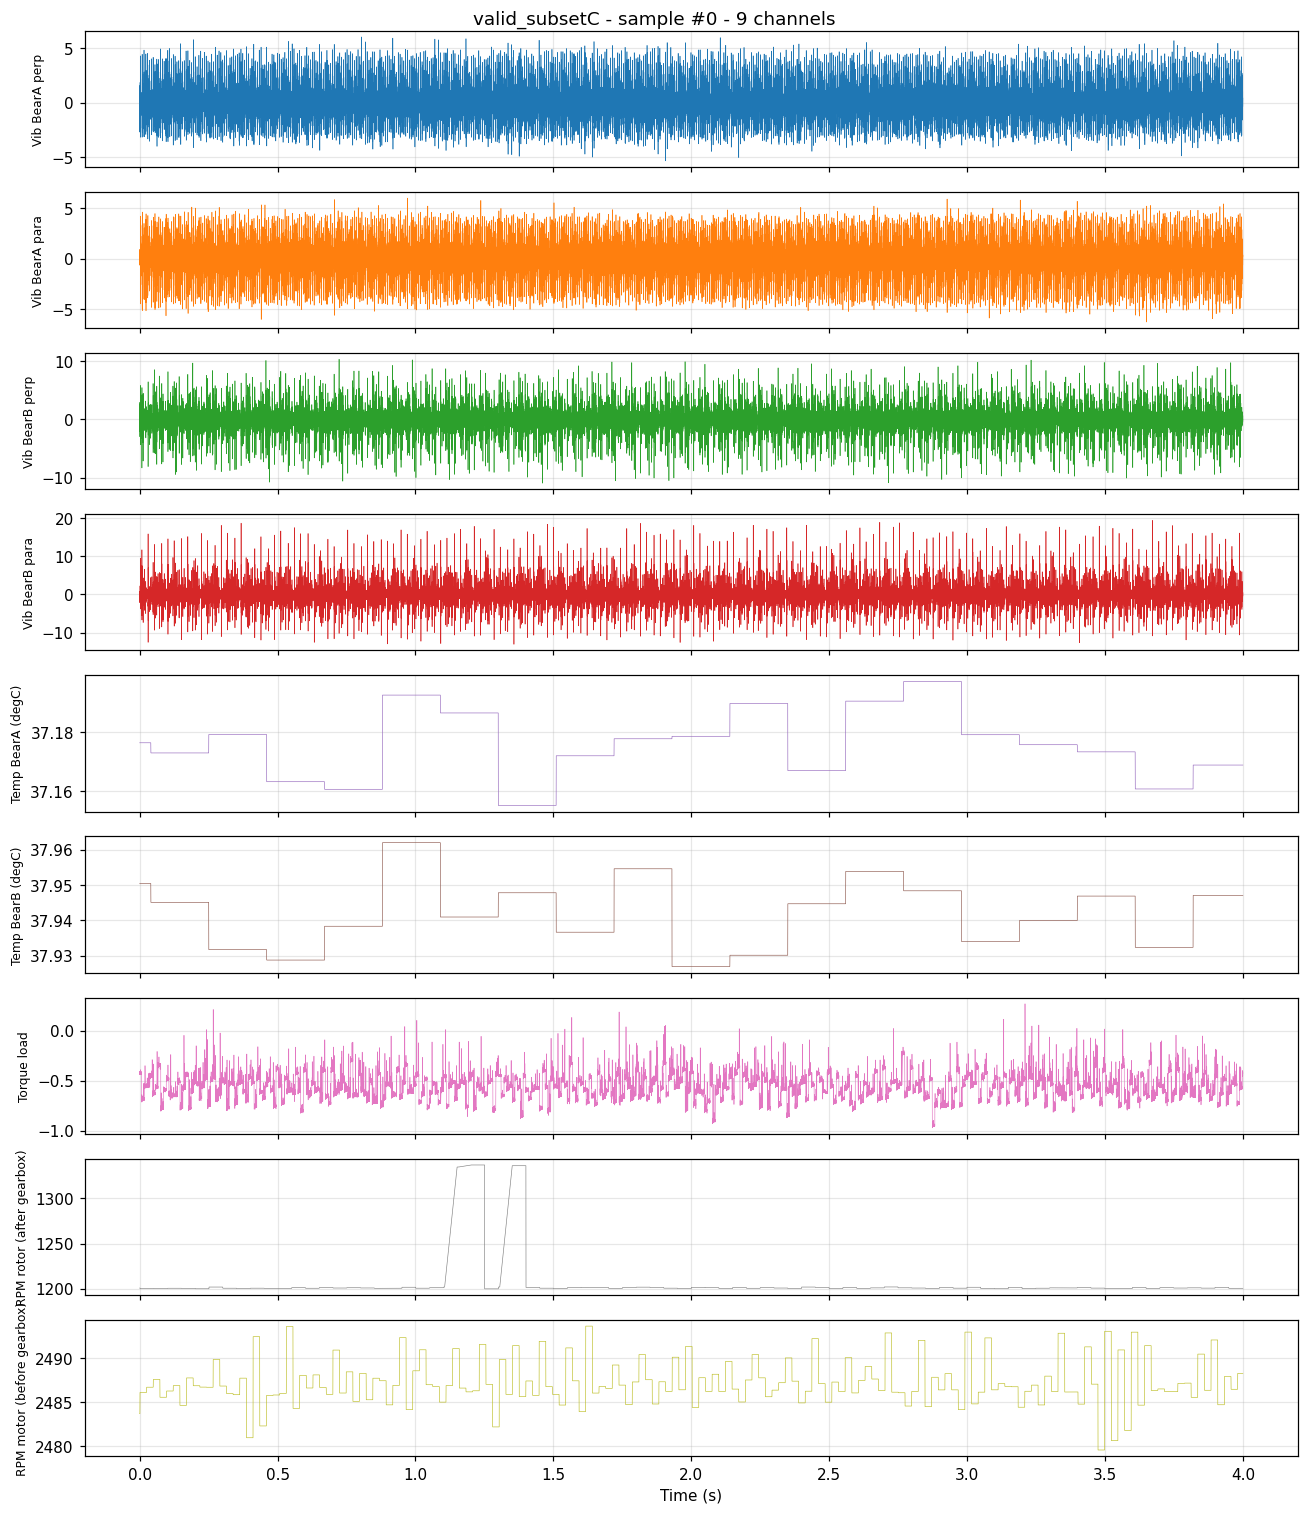

In [21]:
fig, axes = plt.subplots(N_CH, 1, figsize=(12, 14), sharex=True)
for c in range(N_CH):
    axes[c].plot(t, sample[:, c], lw=0.4, color=f'C{c % 10}')
    axes[c].set_ylabel(CH_NAMES[c], fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'{SUBSET} - sample #{SAMPLE_IDX} - 9 channels')
fig.tight_layout()
plt.show()

## 5. Per-channel statistics over 30 random samples

In [22]:
rng = np.random.default_rng(42)
n = min(30, arr.shape[0])
idx = rng.choice(arr.shape[0], size=n, replace=False)
block = np.stack([np.asarray(arr[i]) for i in idx], axis=0)   # (n, T, C)

stats = []
for c in range(N_CH):
    x = block[:, :, c].ravel()
    stats.append({
        'channel': CH_NAMES[c],
        'min': float(x.min()),
        'p01': float(np.percentile(x, 1)),
        'mean': float(x.mean()),
        'p99': float(np.percentile(x, 99)),
        'max': float(x.max()),
        'std': float(x.std()),
    })

import pandas as pd
df = pd.DataFrame(stats)
df.style.format(precision=3)

,channel,min,p01,mean,p99,max,std
0,Vib BearA perp,-7.341,-1.997,0.000,2.057,6.398,0.645
1,Vib BearA para,-10.845,-2.178,0.000,2.210,10.788,0.721
2,Vib BearB perp,-14.448,-3.117,0.003,3.139,14.437,0.988
3,Vib BearB para,-18.525,-3.758,0.039,3.827,25.034,1.222
4,Temp BearA (degC),31.909,31.922,35.006,39.454,39.482,1.855
5,Temp BearB (degC),32.546,32.560,36.621,39.155,39.173,1.883
6,Torque load,-1.029,-0.816,-0.467,-0.020,0.715,0.168
7,RPM rotor (after gearbox),896.318,896.848,1230.870,1552.764,1669.888,194.478
8,RPM motor (before gearbox),1856.081,1858.917,2526.075,3107.353,3115.632,390.720


## 6. PSD (Welch) of the 4 vibration channels

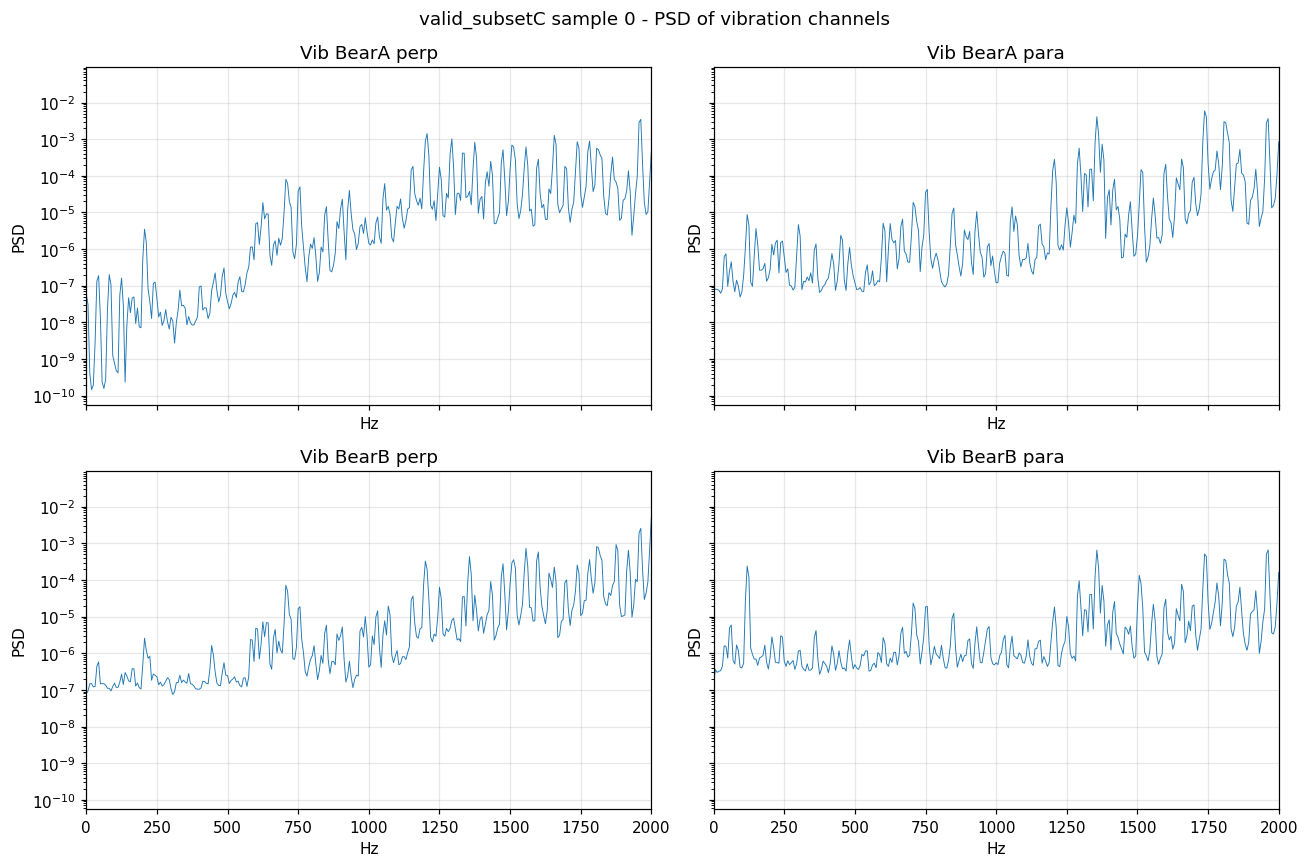

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for c in range(4):
    f, pxx = signal.welch(sample[:, c], fs=FS, nperseg=4096, noverlap=2048)
    axes[c].semilogy(f, pxx, lw=0.6)
    axes[c].set_title(CH_NAMES[c])
    axes[c].set_xlim(0, 2000)
    axes[c].set_xlabel('Hz'); axes[c].set_ylabel('PSD')
fig.suptitle(f'{SUBSET} sample {SAMPLE_IDX} - PSD of vibration channels')
fig.tight_layout()
plt.show()

## 7. STFT — exact preprocessing used by the paper (win 4096, hop 2048, 20–520 Hz, dB scale)

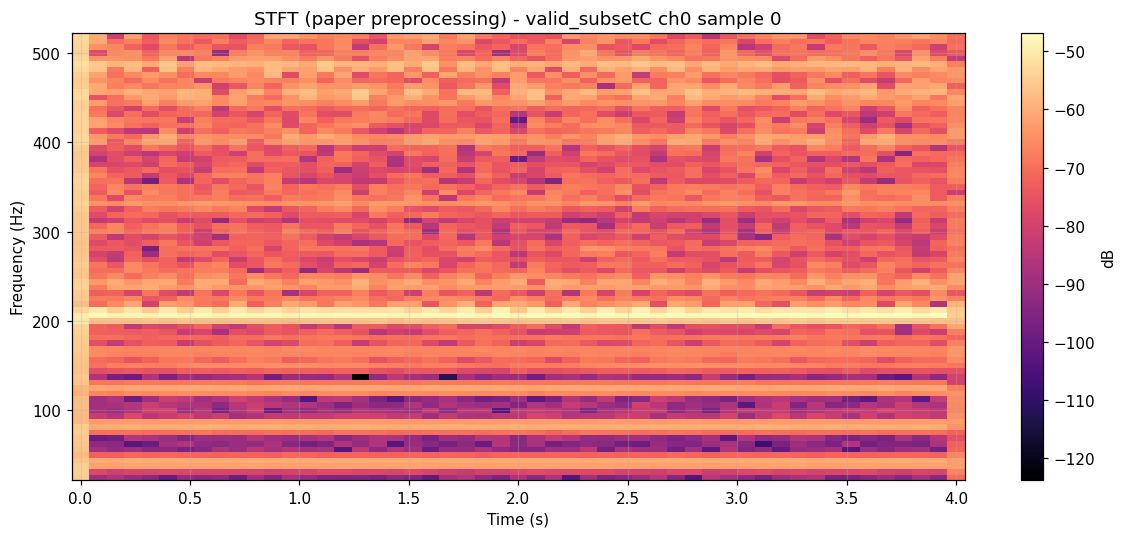

In [24]:
VIB_CH = 0
x = sample[:, VIB_CH]
f, t_stft, Z = signal.stft(x, fs=FS, window='hann',
                            nperseg=4096, noverlap=2048,
                            return_onesided=True)
mag_db = 20 * np.log10(np.abs(Z) + 1e-9)
mask = (f >= 20) & (f <= 520)

fig, ax = plt.subplots(figsize=(11, 5))
pcm = ax.pcolormesh(t_stft, f[mask], mag_db[mask], shading='auto', cmap='magma')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'STFT (paper preprocessing) - {SUBSET} ch{VIB_CH} sample {SAMPLE_IDX}')
fig.colorbar(pcm, ax=ax, label='dB')
fig.tight_layout()
plt.show()

## 8. PSD with bearing-fault frequencies annotated (1×, 2×, BPFO, BPFI)

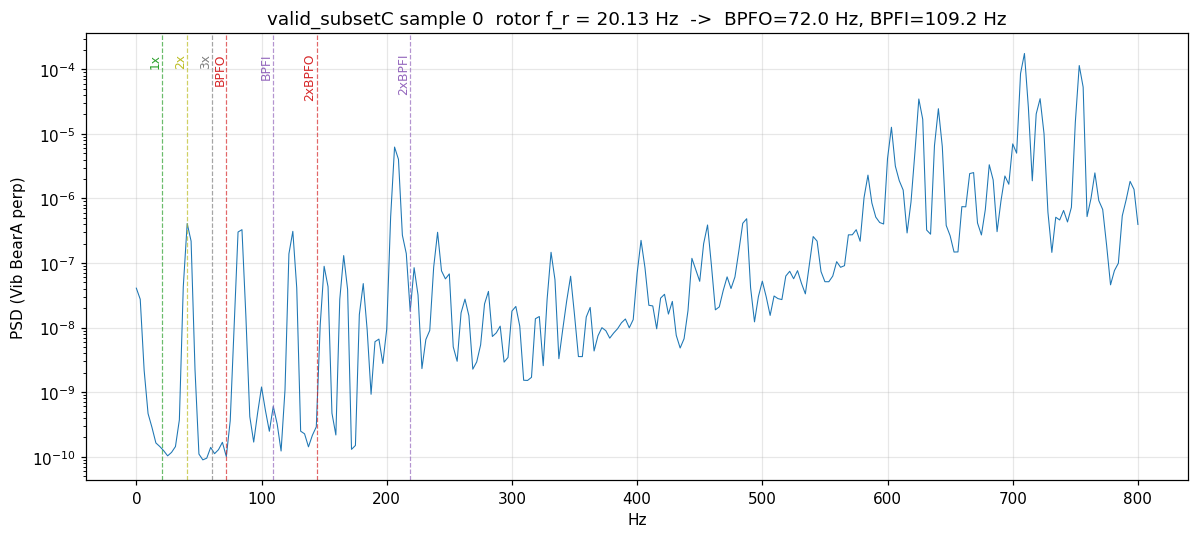

In [25]:
f, pxx = signal.welch(sample[:, 0], fs=FS, nperseg=8192, noverlap=4096)
mask = (f >= 0) & (f <= 800)
fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(f[mask], pxx[mask], lw=0.7, color='C0')
for x_, name, c in [(fr, '1x', 'tab:green'), (2 * fr, '2x', 'tab:olive'),
                    (3 * fr, '3x', 'tab:gray'),
                    (BPFO_R * fr, 'BPFO', 'tab:red'),
                    (2 * BPFO_R * fr, '2xBPFO', 'tab:red'),
                    (BPFI_R * fr, 'BPFI', 'tab:purple'),
                    (2 * BPFI_R * fr, '2xBPFI', 'tab:purple')]:
    ax.axvline(x_, color=c, ls='--', lw=0.8, alpha=0.7)
    ax.text(x_, ax.get_ylim()[1] * 0.5, name, color=c,
            rotation=90, va='top', ha='right', fontsize=8)
ax.set_xlabel('Hz'); ax.set_ylabel('PSD (Vib BearA perp)')
ax.set_title(f'{SUBSET} sample {SAMPLE_IDX}  '
             f'rotor f_r = {fr:.2f} Hz  ->  BPFO={BPFO_R*fr:.1f} Hz, BPFI={BPFI_R*fr:.1f} Hz')
fig.tight_layout()
plt.show()

## 9. ENVELOPE ANALYSIS — Hilbert demodulation

Standard procedure (Randall & Antoni 2011):
1. **Mini-kurtogram** — scan a small set of high-frequency bandpass bands (1–12 kHz) and pick the one whose envelope has the highest **excess kurtosis**. This is the structural-resonance band where bearing impacts ring out and get amplitude-modulated.
2. **Bandpass + Hilbert** — zero-phase Butterworth bandpass, then `env = |hilbert(y)|`.
3. **Envelope spectrum** — FFT of the (DC-removed) envelope. Peaks at `BPFO`, `BPFI`, `FTF`, `BSF` and their harmonics indicate impulses repeating at those bearing characteristic frequencies — i.e. a bearing fault.

**Note:** Bands below 1 kHz are deliberately excluded — they are dominated by tonal shaft / gear harmonics that have high kurtosis but are unrelated to bearing impacts.

### 9.1 Helper functions

In [26]:
def envelope_bandpass(x, fs, lo, hi, order=4):
    nyq = 0.5 * fs
    sos = signal.butter(order, [lo / nyq, hi / nyq], btype='bandpass', output='sos')
    y = signal.sosfiltfilt(sos, x)
    env = np.abs(signal.hilbert(y))
    return y, env - env.mean()

def envelope_spectrum(env, fs):
    n = len(env)
    win = signal.windows.hann(n)
    X = np.fft.rfft(env * win)
    f = np.fft.rfftfreq(n, 1 / fs)
    mag = (2 / (n * win.mean())) * np.abs(X)
    return f, mag

def kurtogram_scan(x, fs=FS):
    bands = [(1000, 2500), (2500, 4000), (4000, 6000), (6000, 8000),
             (8000, 10500), (10500, 12500), (1500, 5000), (3000, 7000)]
    res = []
    for lo, hi in bands:
        _, env = envelope_bandpass(x, fs, lo, hi)
        res.append(((lo, hi), float(kurtosis(env, fisher=True, bias=False))))
    res.sort(key=lambda r: r[1], reverse=True)
    return res

def annotate_envelope(ax, fr):
    items = [(fr, '1xfr', 'tab:green'), (2 * fr, '2xfr', 'tab:olive'),
             (FTF_R * fr, 'FTF', 'tab:cyan'),
             (BSF_R * fr, 'BSF', 'tab:orange'),
             (BPFO_R * fr, 'BPFO', 'tab:red'),
             (2 * BPFO_R * fr, '2xBPFO', 'tab:red'),
             (3 * BPFO_R * fr, '3xBPFO', 'tab:red'),
             (BPFI_R * fr, 'BPFI', 'tab:purple'),
             (2 * BPFI_R * fr, '2xBPFI', 'tab:purple')]
    ymax = ax.get_ylim()[1]
    for x, name, c in items:
        if x > ax.get_xlim()[1]:
            continue
        ax.axvline(x, color=c, ls='--', lw=0.7, alpha=0.7)
        ax.text(x, ymax * 0.92, name, color=c, rotation=90,
                va='top', ha='right', fontsize=7)

print('helpers ready')

helpers ready


### 9.2 Mini-kurtogram → pick the best demodulation band

  band 10500-12500 Hz  ->  excess kurtosis = 6.67
  band  3000- 7000 Hz  ->  excess kurtosis = 6.25
  band  4000- 6000 Hz  ->  excess kurtosis = 5.08
  band  1500- 5000 Hz  ->  excess kurtosis = 2.78
  band  2500- 4000 Hz  ->  excess kurtosis = 1.09
  band  1000- 2500 Hz  ->  excess kurtosis = 0.91
  band  8000-10500 Hz  ->  excess kurtosis = 0.68
  band  6000- 8000 Hz  ->  excess kurtosis = 0.02

Best band = 10500-12500 Hz


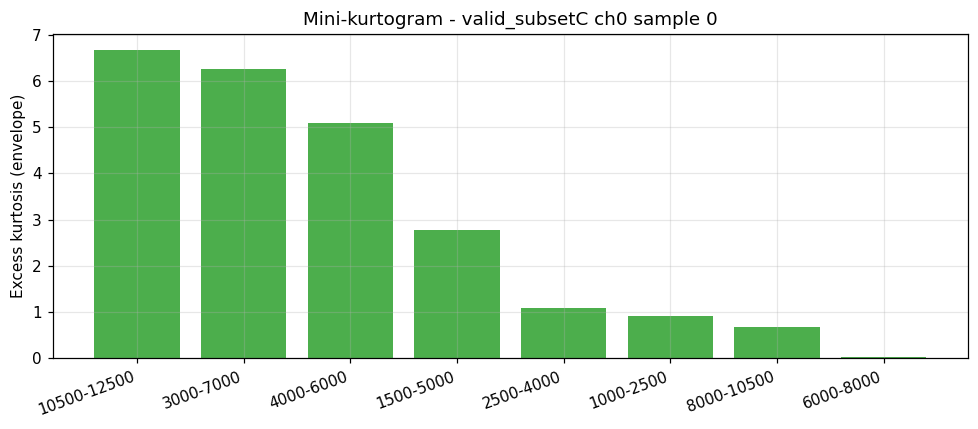

In [27]:
VIB_CH_ENV = 0   # set 0/1/2/3 to switch vibration channel
x_vib = sample[:, VIB_CH_ENV]
results = kurtogram_scan(x_vib)
for (lo, hi), k in results:
    print(f'  band {lo:>5d}-{hi:>5d} Hz  ->  excess kurtosis = {k:.2f}')
best_band = results[0][0]
print(f'\nBest band = {best_band[0]}-{best_band[1]} Hz')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'{lo}-{hi}' for (lo, hi), _ in results], [k for _, k in results], color='C2', alpha=0.85)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Excess kurtosis (envelope)')
ax.set_title(f'Mini-kurtogram - {SUBSET} ch{VIB_CH_ENV} sample {SAMPLE_IDX}')
fig.autofmt_xdate(rotation=20)
fig.tight_layout()
plt.show()

### 9.3 Bandpass + envelope + envelope spectrum

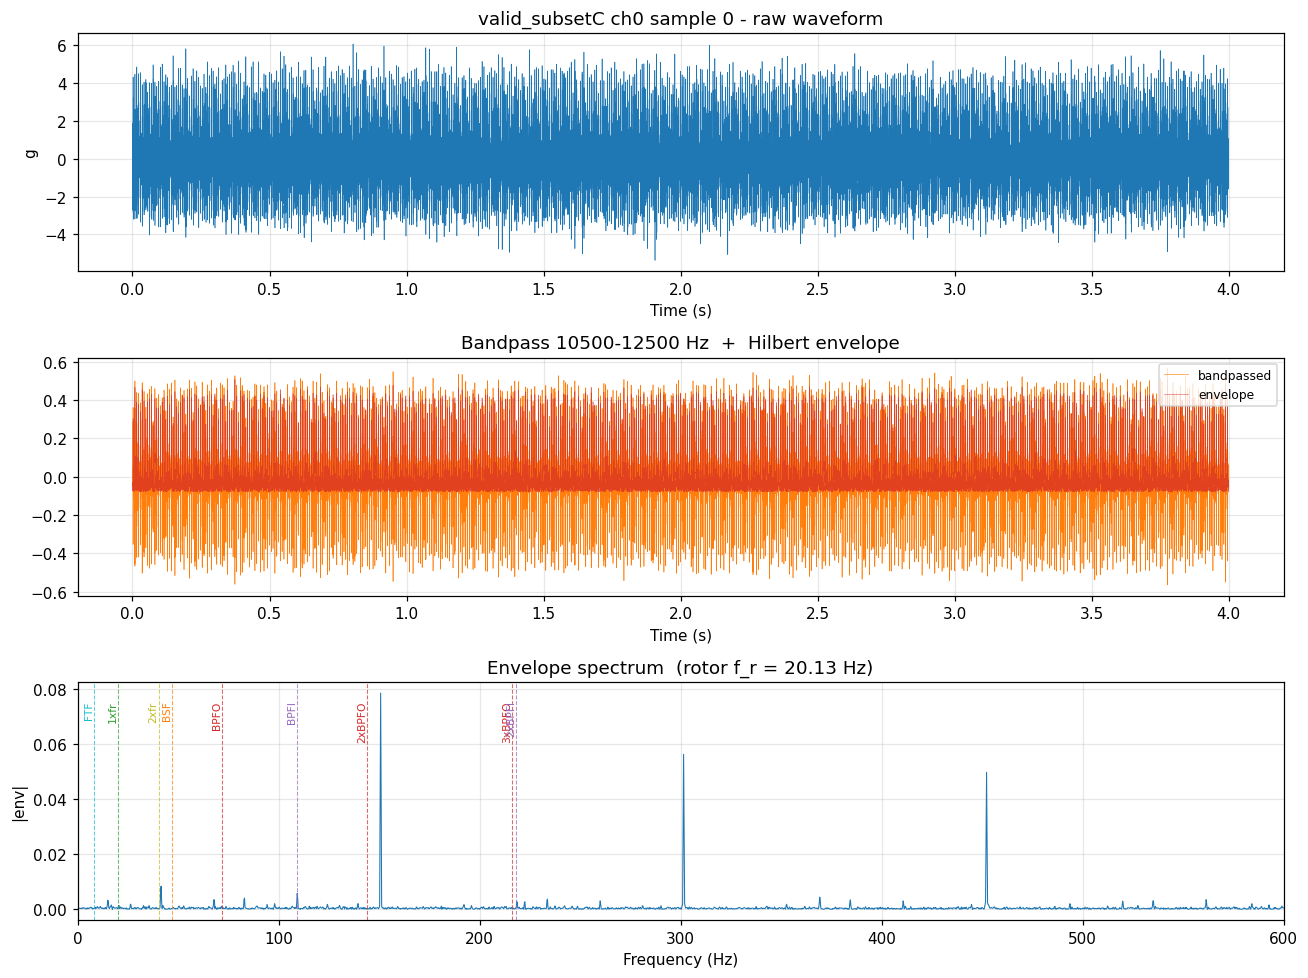

In [28]:
lo, hi = best_band
y_bp, env = envelope_bandpass(x_vib, FS, lo, hi)
f_env, mag_env = envelope_spectrum(env, FS)
mask = (f_env >= 0) & (f_env <= 600)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(t, x_vib, lw=0.4, color='C0')
axes[0].set_title(f'{SUBSET} ch{VIB_CH_ENV} sample {SAMPLE_IDX} - raw waveform')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('g')

axes[1].plot(t, y_bp, lw=0.4, color='C1', label='bandpassed')
axes[1].plot(t, env + env.mean(), lw=0.4, color='C3', alpha=0.7, label='envelope')
axes[1].set_title(f'Bandpass {lo}-{hi} Hz  +  Hilbert envelope')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlabel('Time (s)')

axes[2].plot(f_env[mask], mag_env[mask], lw=0.7, color='C0')
axes[2].set_xlim(0, 600); axes[2].set_xlabel('Frequency (Hz)'); axes[2].set_ylabel('|env|')
axes[2].set_title(f'Envelope spectrum  (rotor f_r = {fr:.2f} Hz)')
annotate_envelope(axes[2], fr)
fig.tight_layout()
plt.show()

### 9.4 Envelope-spectrum grid for 9 samples of subset C

Subset C runs at constant RPM, so the BPFO / BPFI annotation lines stay fixed — easy to compare side by side. Each sample is a different (IRF, ORF, misalign, unbalance) combination, so the envelope pattern should change visibly across classes.

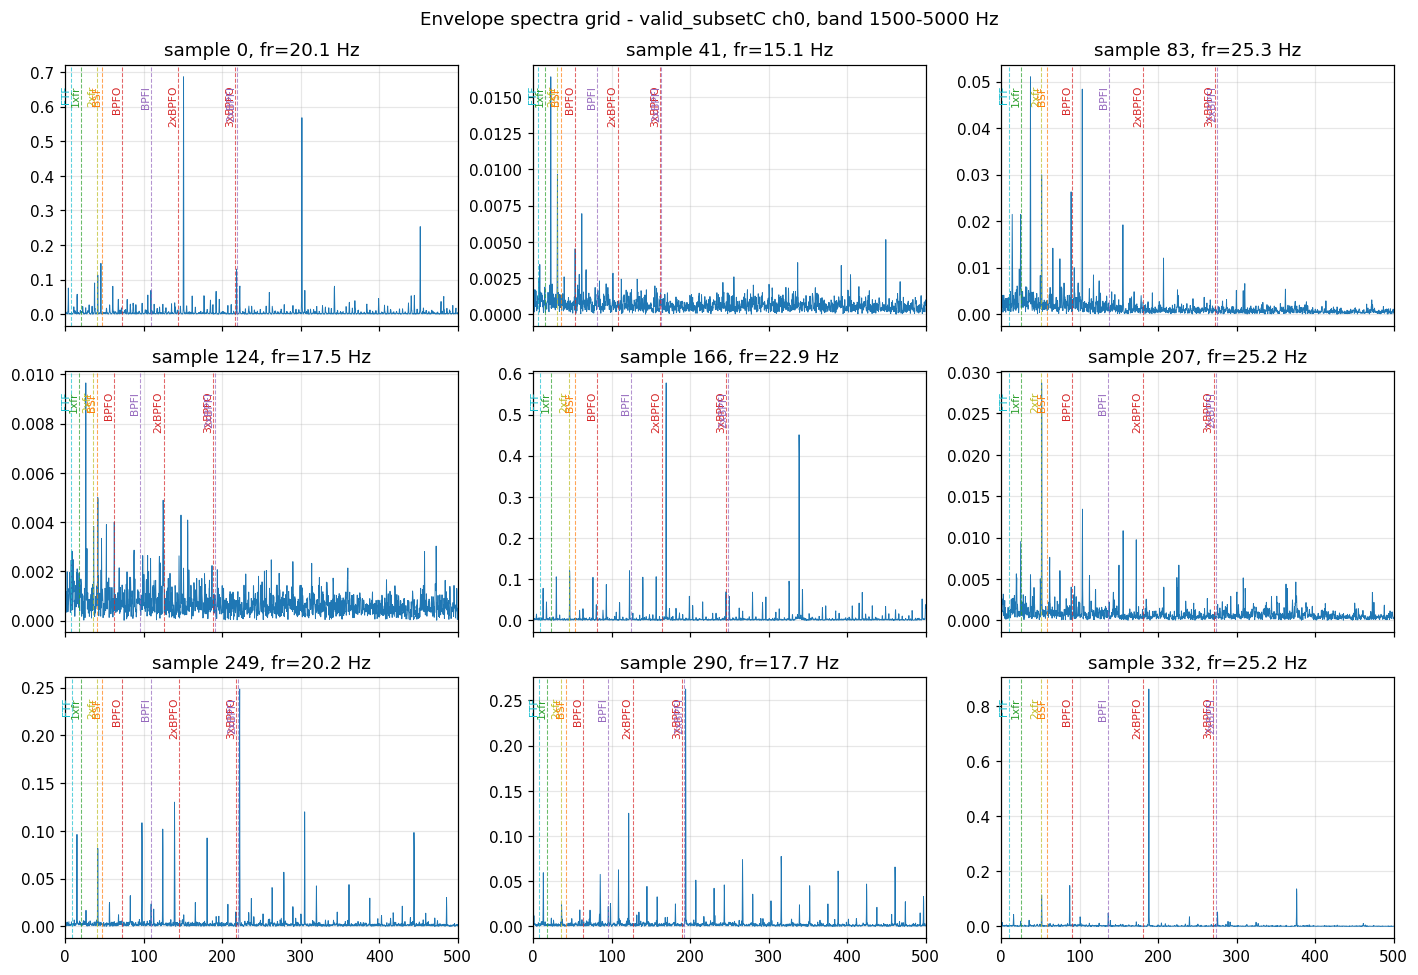

In [29]:
if 'valid_subsetC' in arrs:
    arr_c = arrs['valid_subsetC']
    n_c = arr_c.shape[0]
    sample_indices = [int(i) for i in np.linspace(0, n_c - 1, 9, dtype=int)]
    band = (1500, 5000)
    fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
    axes = axes.ravel()
    for ax, idx in zip(axes, sample_indices):
        s_ = np.asarray(arr_c[idx, :, 0])
        _, env_ = envelope_bandpass(s_, FS, *band)
        f_, mag_ = envelope_spectrum(env_, FS)
        rotor_ = float(np.asarray(arr_c[idx, ::256, 7]).mean())
        fr_ = rotor_ / 60
        m_ = (f_ >= 0) & (f_ <= 500)
        ax.plot(f_[m_], mag_[m_], lw=0.6)
        ax.set_xlim(0, 500); ax.set_title(f'sample {idx}, fr={fr_:.1f} Hz')
        annotate_envelope(ax, fr_)
    fig.suptitle(f'Envelope spectra grid - valid_subsetC ch0, band {band[0]}-{band[1]} Hz')
    fig.tight_layout()
    plt.show()

## 10. Motor RPM trace — comparison across subsets

Clear distinctions: **subsetA = sinusoidal**, **subsetB = triangular**, **subsetC = constant (5 levels)**, **subsetE = mix of all conditions** (confirmed via Zenodo).

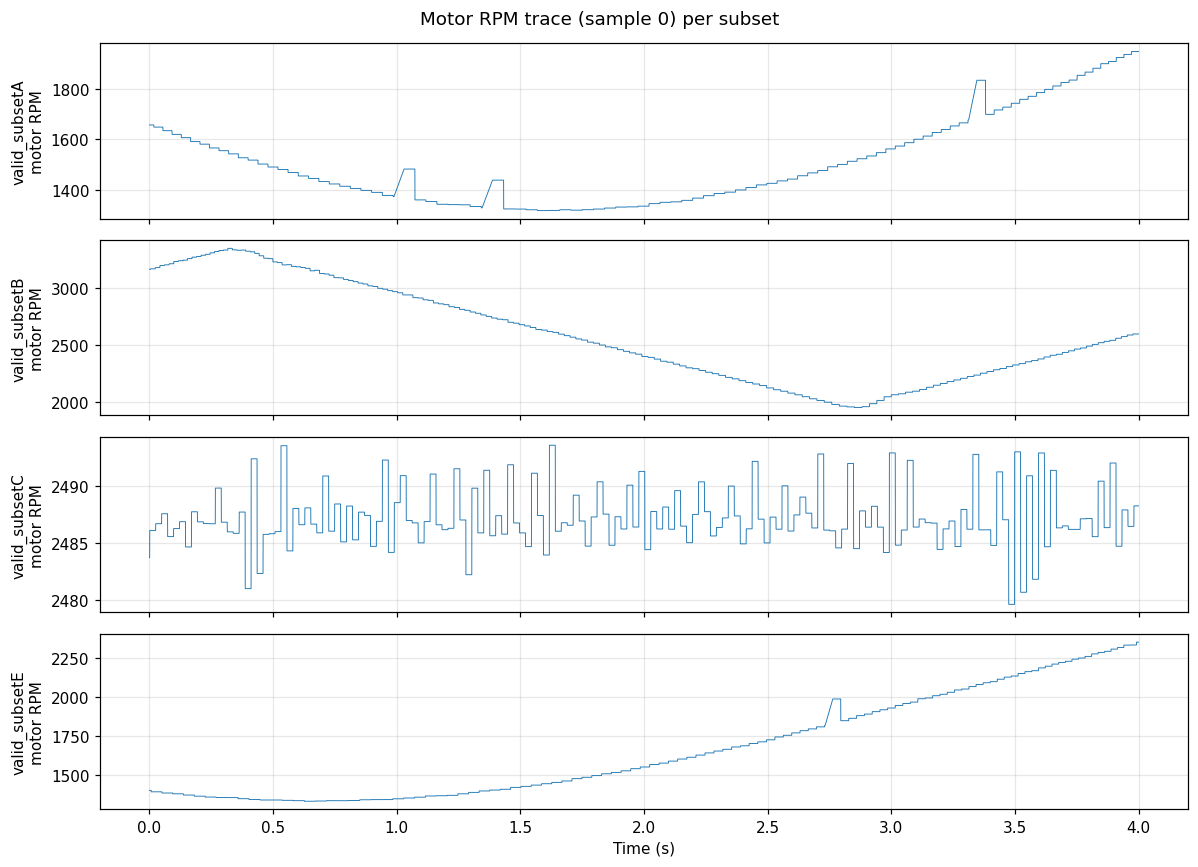

In [30]:
to_show = ['valid_subsetA', 'valid_subsetB', 'valid_subsetC', 'valid_subsetE']
to_show = [k for k in to_show if k in arrs]
fig, axes = plt.subplots(len(to_show), 1, figsize=(11, 2.0 * len(to_show)), sharex=True)
if len(to_show) == 1:
    axes = [axes]
for ax, name in zip(axes, to_show):
    s = np.asarray(arrs[name][0, :, 8])
    ax.plot(t, s, lw=0.6)
    ax.set_ylabel(f'{name}\nmotor RPM')
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Motor RPM trace (sample 0) per subset')
fig.tight_layout()
plt.show()

## 11. Boxplot of motor RPM — operating-condition coverage per subset

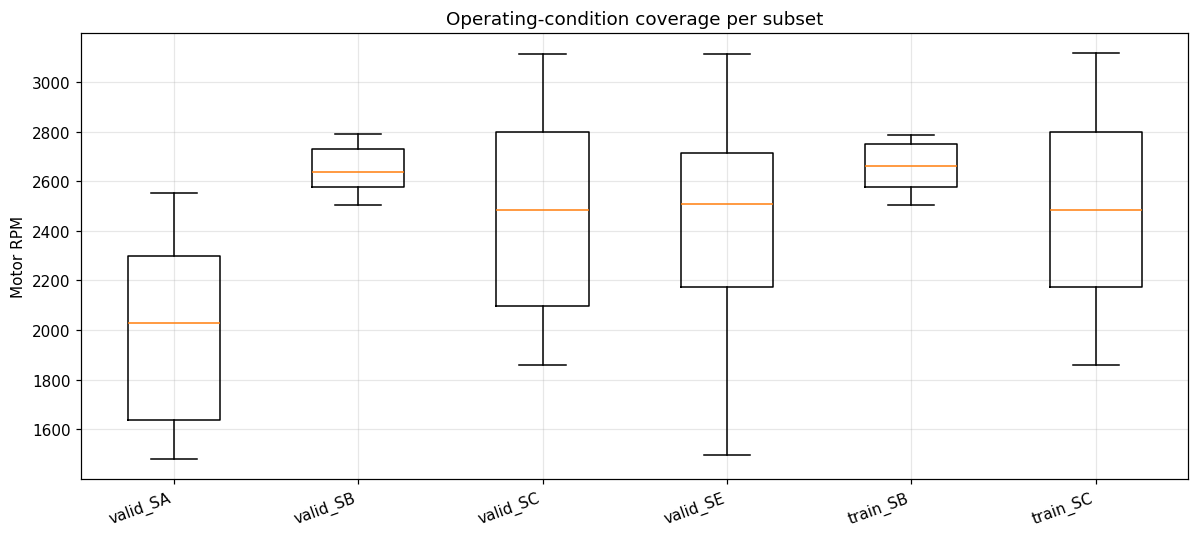

In [31]:
data, labels = [], []
for name, a in arrs.items():
    n_ = min(200, a.shape[0])
    rpm = np.asarray(a[:n_, ::256, 8]).mean(axis=1)
    data.append(rpm); labels.append(name.replace('subset', 'S'))
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.set_ylabel('Motor RPM'); ax.set_title('Operating-condition coverage per subset')
fig.autofmt_xdate(rotation=20)
fig.tight_layout()
plt.show()

## 12. 9 × 9 inter-channel correlation matrix in the selected subset

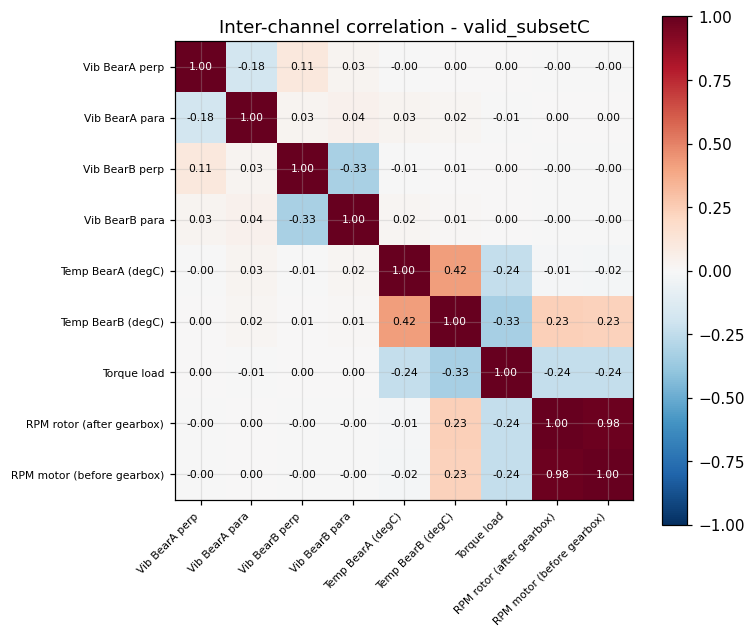

In [32]:
block_ds = block[:, ::64, :].reshape(-1, N_CH)
corr = np.corrcoef(block_ds.T)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(N_CH):
    for j in range(N_CH):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center',
                fontsize=7,
                color='black' if abs(corr[i, j]) < 0.6 else 'white')
ax.set_xticks(range(N_CH)); ax.set_yticks(range(N_CH))
ax.set_xticklabels(CH_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(CH_NAMES, fontsize=7)
ax.set_title(f'Inter-channel correlation - {SUBSET}')
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

## 13. Sanity-check the gear ratio (ch8 / ch7)

Per the paper: gearbox ratio = **2.07**.

ratio (ch8/ch7): median=2.054, mean=2.053 +- 0.009
Expected gear ratio (paper): 2.07


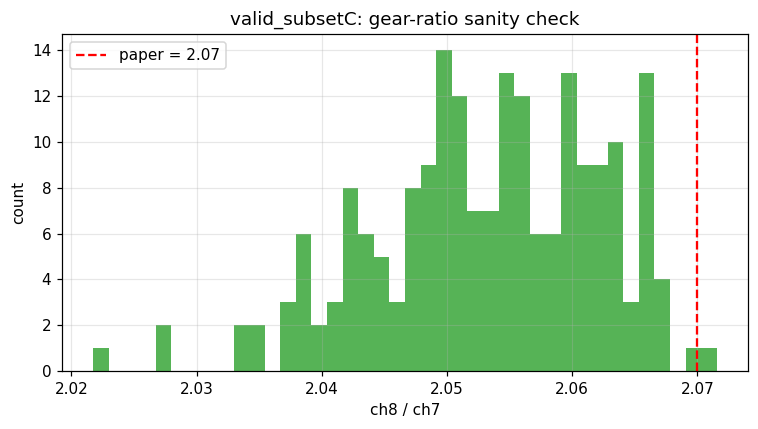

In [33]:
n_ = min(200, arr.shape[0])
ch7 = np.asarray(arr[:n_, ::1024, 7]).mean(axis=1)
ch8 = np.asarray(arr[:n_, ::1024, 8]).mean(axis=1)
ratio = ch8 / np.where(ch7 == 0, 1, ch7)
print(f'ratio (ch8/ch7): median={np.median(ratio):.3f}, '
      f'mean={ratio.mean():.3f} +- {ratio.std():.3f}')
print('Expected gear ratio (paper): 2.07')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ratio, bins=40, color='C2', alpha=0.8)
ax.axvline(2.07, color='r', ls='--', label='paper = 2.07')
ax.set_xlabel('ch8 / ch7'); ax.set_ylabel('count'); ax.legend()
ax.set_title(f'{SUBSET}: gear-ratio sanity check')
fig.tight_layout()
plt.show()

## 14. Vibration PSD comparison across subsets (visualising domain shift)

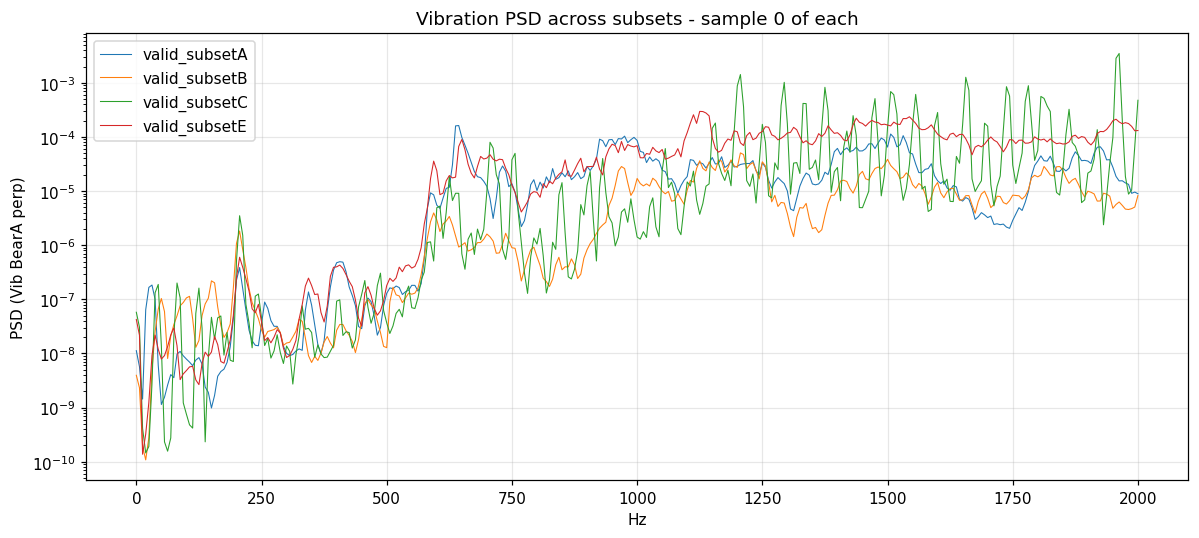

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
for name in ['valid_subsetA', 'valid_subsetB', 'valid_subsetC', 'valid_subsetE']:
    if name not in arrs:
        continue
    x_ = np.asarray(arrs[name][0, :, 0])
    f_, pxx_ = signal.welch(x_, fs=FS, nperseg=4096, noverlap=2048)
    m = (f_ >= 0) & (f_ <= 2000)
    ax.semilogy(f_[m], pxx_[m], lw=0.7, label=name)
ax.set_xlabel('Hz'); ax.set_ylabel('PSD (Vib BearA perp)')
ax.set_title('Vibration PSD across subsets - sample 0 of each')
ax.legend()
fig.tight_layout()
plt.show()

---
**Suggested next steps**

1. Change `SUBSET` & `SAMPLE_IDX` (cell §3) and `VIB_CH_ENV` (cell §9.2) to browse different samples / channels.
2. Once Zenodo Part 1 is downloaded successfully, load `*_npy_name_*.npy` to attach IRF / ORF / Misalign / Unbalance class labels to each sample → group envelope spectra by class.
3. With labels available → train a small classifier using just **6 envelope features** (peak amplitudes at 1xfr, 2xfr, BPFO, 2xBPFO, BPFI, 2xBPFI) as a rule-based baseline, then compare with the paper's MOC RNDR.
4. Cast `float64 → float32` and store as chunked HDF5 if you actually train models (saves 50 % RAM / VRAM).